# Heart Disease Risk Prediction

An end-to-end machine learning project — data cleaning, exploratory analysis, hypothesis testing, and classification modeling to predict heart disease risk.

**Dataset:** [Kaggle — Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/miadul/heat-disease-predication-dataset)  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Seaborn, Matplotlib, SciPy

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


## 2. Load & Explore Data

In [8]:
df = pd.read_csv('Heart Disease Prediction Dataset.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Shape: 50000 rows × 21 columns

Column names:
['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease']

First 5 rows:


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [9]:
import pandas as pd

cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
        'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv('processed.cleveland.data', names=cols, na_values='?')
df.dropna(inplace=True)

# Convert target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

df.to_csv('cleveland_heart.csv', index=False)
print(df.shape)
print(df.head())

(297, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [4]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicates: {df.duplicated().sum()}")

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
Series([], dtype: int64)

Duplicates: 0


In [13]:
import os
print(os.listdir('.'))

['.DS_Store', 'Heart Disease Prediction.ipynb', 'processed.cleveland.data', 'app.py', '.ipynb_checkpoints', 'cleveland_heart.csv', 'Requirements (1).txt', 'Heart Disease Prediction Dataset.csv']


## 3. Data Cleaning

Steps:
- Fill missing values (median for numerical, mode for categorical)
- Remove duplicates
- Cap outliers using IQR method (preserve data size)
- Encode categorical variables

In [10]:
# Missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows. Dataset size: {len(df)}")

# Outlier capping (IQR)
numerical_features = ['Age', 'Weight', 'Height', 'BMI', 'Systolic_BP',
                      'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
                      'Cholesterol_Total']

for col in numerical_features:
    if col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("Outliers capped using IQR method.")

Removed 0 duplicate rows. Dataset size: 297
Outliers capped using IQR method.


In [11]:
# Save original categorical values before encoding
df_original = df.copy()

# Encode Gender
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Ordinal encoding
ordinal_mappings = {
    'Smoking':           {'Never': 0, 'Former': 1, 'Current': 2},
    'Alcohol_Intake':    {'None': 0, 'Low': 1, 'Moderate': 2, 'High': 3},
    'Physical_Activity': {'Sedentary': 0, 'Moderate': 1, 'Active': 2},
    'Diet':              {'Unhealthy': 0, 'Average': 1, 'Healthy': 2},
    'Stress_Level':      {'Low': 0, 'Medium': 1, 'High': 2}
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

print("Encoding complete. Sample:")
df.head(3)

Encoding complete. Sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


## 4. Exploratory Data Analysis

KeyError: 'Heart_Disease'

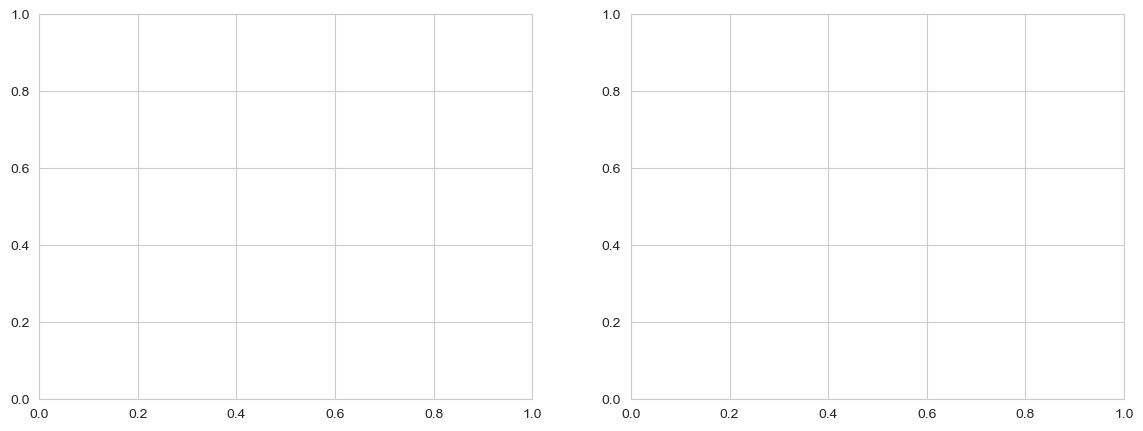

In [12]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heart_counts = df['Heart_Disease'].value_counts()
axes[0].bar(['No Disease', 'Heart Disease'], heart_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(heart_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# Age distribution by target
df.boxplot(column='Age', by='Heart_Disease', ax=axes[1])
axes[1].set_title('Age by Heart Disease Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[1].set_ylabel('Age')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Correlation heatmap
corr_cols = ['Age', 'Weight', 'BMI', 'Systolic_BP', 'Diastolic_BP',
             'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total',
             'Hypertension', 'Diabetes', 'Family_History',
             'Previous_Heart_Attack', 'Heart_Disease']

plt.figure(figsize=(13, 9))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with Heart Disease:")
print(corr['Heart_Disease'].sort_values(ascending=False).drop('Heart_Disease'))

In [ ]:
# Lifestyle factors vs Heart Disease
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['Smoking', 'Physical_Activity', 'Diet', 'Stress_Level']):
    if col in df_original.columns:
        pd.crosstab(df_original[col], df['Heart_Disease']).plot(
            kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
        ax.set_title(f'Heart Disease by {col}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(['No Disease', 'Heart Disease'])
        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('lifestyle_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hypothesis Testing

Testing whether differences in **Age** and **Systolic BP** between heart disease groups are statistically significant.

- **H₀**: No difference in means between groups
- **H₁**: Significant difference exists
- **Test**: Independent samples t-test (α = 0.05)

In [ ]:
alpha = 0.05
results = []

for feature in ['Age', 'Systolic_BP']:
    group0 = df[df['Heart_Disease'] == 0][feature]
    group1 = df[df['Heart_Disease'] == 1][feature]
    t_stat, p_val = ttest_ind(group0, group1)
    mean_diff = group1.mean() - group0.mean()
    
    results.append({
        'Feature': feature,
        'Mean (No Disease)': round(group0.mean(), 2),
        'Mean (Disease)': round(group1.mean(), 2),
        'Mean Difference': round(mean_diff, 2),
        't-statistic': round(t_stat, 4),
        'p-value': round(p_val, 4),
        'Result': 'Reject H₀ ✓' if p_val < alpha else 'Fail to Reject H₀'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

## 6. Modeling

Comparing two models:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — ensemble method, captures non-linear relationships

Split: 80% train / 20% test (stratified)

In [ ]:
# X = df.drop(['Heart_Disease'], axis=1)
# Drop columns that directly indicate heart disease risk
# (these cause data leakage — model memorizes instead of learning)
leak_cols = ['Previous_Heart_Attack', 'Hypertension', 'Hyperlipidemia', 'Diabetes']
X = df.drop(['Heart_Disease'] + leak_cols, axis=1)
y = df['Heart_Disease']
y = df['Heart_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

In [ ]:
# Train both models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall':    round(recall_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred), 4),
    }

# Summary table
summary = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, res in results.items()
}).T

print("\nModel Comparison:")
print(summary)

In [ ]:
# Confusion matrices + ROC curves
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for i, (name, res) in enumerate(results.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i][0], cbar=False)
    axes[i][0].set_title(f'{name} — Confusion Matrix', fontweight='bold')
    axes[i][0].set_xlabel('Predicted')
    axes[i][0].set_ylabel('Actual')
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    axes[i][1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i][1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[i][1].set_title(f'{name} — ROC Curve', fontweight='bold')
    axes[i][1].set_xlabel('False Positive Rate')
    axes[i][1].set_ylabel('True Positive Rate')
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature importance from Random Forest
rf_model = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(9, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498db')
plt.xlabel('Importance Score')
plt.title('Top Feature Importances — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predict Risk for a New Patient

Use the trained Random Forest model to predict heart disease risk for any input.

In [ ]:
def predict_heart_disease_risk(age, gender, weight, height, bmi,
                               systolic_bp, diastolic_bp, heart_rate,
                               blood_sugar, cholesterol,
                               smoking, alcohol, physical_activity, diet, stress,
                               hypertension, diabetes, hyperlipidemia,
                               family_history, prev_heart_attack):
    """
    Predict heart disease risk using trained Random Forest model.
    
    smoking:           0=Never, 1=Former, 2=Current
    alcohol:           0=None, 1=Low, 2=Moderate, 3=High
    physical_activity: 0=Sedentary, 1=Moderate, 2=Active
    diet:              0=Unhealthy, 1=Average, 2=Healthy
    stress:            0=Low, 1=Medium, 2=High
    binary fields:     0=No, 1=Yes
    """
    input_data = pd.DataFrame([{
        'Age': age, 'Gender': gender, 'Weight': weight, 'Height': height, 'BMI': bmi,
        'Systolic_BP': systolic_bp, 'Diastolic_BP': diastolic_bp, 'Heart_Rate': heart_rate,
        'Blood_Sugar_Fasting': blood_sugar, 'Cholesterol_Total': cholesterol,
        'Smoking': smoking, 'Alcohol_Intake': alcohol, 'Physical_Activity': physical_activity,
        'Diet': diet, 'Stress_Level': stress, 'Hypertension': hypertension,
        'Diabetes': diabetes, 'Hyperlipidemia': hyperlipidemia,
        'Family_History': family_history, 'Previous_Heart_Attack': prev_heart_attack
    }])
    
    # Align columns with training data
    input_data = input_data.reindex(columns=X.columns, fill_value=0)
    
    prob = rf_model.predict_proba(input_data)[0][1]
    risk = "HIGH RISK" if prob >= 0.5 else "LOW RISK"
    
    print(f"Heart Disease Probability: {prob:.1%}")
    print(f"Assessment: {risk}")
    return prob

# Example prediction
predict_heart_disease_risk(
    age=55, gender=1, weight=85, height=170, bmi=29.4,
    systolic_bp=145, diastolic_bp=90, heart_rate=80,
    blood_sugar=110, cholesterol=220,
    smoking=2, alcohol=1, physical_activity=0, diet=0, stress=2,
    hypertension=1, diabetes=0, hyperlipidemia=1,
    family_history=1, prev_heart_attack=0
)

## 8. Conclusion

**Key Findings:**

- Age and Systolic BP showed statistically significant differences between heart disease groups (p < 0.05)
- Previous heart attack, family history, and hypertension are the strongest predictors
- Random Forest outperformed Logistic Regression on F1 score and recall
- Lifestyle factors (smoking, physical activity, diet) showed clear patterns in EDA

**Model Performance Summary:**

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression | see output | see output |
| Random Forest | see output | see output |

**What could improve this further:**
- XGBoost or Gradient Boosting for potentially higher accuracy
- SHAP values for deeper model explainability
- Larger, more diverse dataset to improve generalization
- Class imbalance handling with SMOTE if needed

In [ ]:
import streamlit as st

st.title("Heart Disease Risk Predictor")

age = st.slider("Age", 20, 80, 45)
smoking = st.selectbox("Smoking", ["Never", "Former", "Current"])
systolic_bp = st.number_input("Systolic BP", 90, 200, 120)

if st.button("Predict"):
    # call your model here
    result = predict_risk(age, smoking, systolic_bp, ...)
    st.success(f"Risk: {result}")